##### Title: Predicting Workforce Burnout Risk Using Economic and Behavioral Indicators
##### Author: Allyson Totpal
##### Date: 8 March 2026
##### Modified By: Allyson Totpal
##### Description: This project seeks to address is whether workforce burnout risk can be predicted using publicly available economic, labor market, and mental health indicators.

In [2]:
import os
import re
import json
import requests
import numpy as np
import pandas as pd

In [3]:
# define analysis year range
start_year = 2016
end_year = 2026

bea_api_url = 'https://apps.bea.gov/api/data'
bea_api_key = os.getenv('bls_api_key', 'E40FE19C-D71C-4C44-AB85-6D7CEA7B7051')

# load hps and google trends files
hps = pd.read_csv('/Users/smooshii/DSC680/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days_20260301.csv')
trends = pd.read_csv('/Users/smooshii/DSC680/time_series_US_20160101-0000_20260301-1159.csv')

In [4]:
# state helpers
state_abbr_to_name = {'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
                      'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'DC': 'District of Columbia', 'FL': 'Florida',
                      'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
                      'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan',
                      'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
                      'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
                      'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
                      'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
                      'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'}
# reverse mapping from full state names to abbreviations
state_name_to_abbr = {v: k for k, v in state_abbr_to_name.items()}

#### Household Pulse Survey

In [6]:
# hps clean
hps = hps[hps['Group'].eq('By State')].copy()

# parse date and create quarter
hps['date'] = pd.to_datetime(hps['Time Period End Date'], errors = 'coerce')
hps = hps[hps['date'].notna()].copy()
hps['quarter'] = hps['date'].dt.to_period('Q').astype(str)

# map state names to abbreviations
hps['state'] = hps['State'].astype(str).str.strip().map(state_name_to_abbr)
hps = hps[hps['state'].isin(state_abbr_to_name.keys())].copy()

# keep only anxiety + depression
keep_inds = ['Symptoms of Anxiety Disorder', 'Symptoms of Depressive Disorder']
hps = hps[hps['Indicator'].isin(keep_inds)].copy()

# ensure numeric
hps['Value'] = pd.to_numeric(hps['Value'], errors = 'coerce')

# pivot to columns and aggregate quarterly mean (percent)
hps_q = (hps.pivot_table(index = ['state', 'quarter'],
                         columns = 'Indicator',
                         values = 'Value',
                         aggfunc = 'mean').reset_index().rename(columns = {'Symptoms of Anxiety Disorder': 'hps_anxiety_pct',
                                                                           'Symptoms of Depressive Disorder': 'hps_depression_pct'})
        )

# filter years
hps_q['year'] = hps_q['quarter'].str.slice(0, 4).astype(int)
hps_q = hps_q[(hps_q['year'] >= start_year) & (hps_q['year'] <= end_year)].drop(columns = ['year'])

hps_q.head()

Indicator,state,quarter,hps_anxiety_pct,hps_depression_pct
0,AK,2020Q2,29.200000,23.733333
1,AK,2020Q3,30.833333,24.550000
2,AK,2020Q4,35.516667,28.100000
3,AK,2021Q1,33.466667,27.333333
4,AK,2021Q2,26.140000,21.140000


#### Google Trends

In [8]:
# google trends clean
trends['date'] = pd.to_datetime(trends['Time'], errors = 'coerce')
trends = trends[trends['date'].notna()].copy()

term_cols = [c for c in trends.columns if c not in ['Time', 'date']]
for c in term_cols:
    trends[c] = (trends[c].astype(str)
                 .str.replace('<1', '0.5', regex = 'False')
                 .str.strip())
    trends[c] = pd.to_numeric(trends[c], errors = 'coerce')

# drop any completely non-numeric columns
term_cols = [c for c in term_cols if pd.api.types.is_numeric_dtype(trends[c])]

# convert to quarter
trends['quarter'] = trends['date'].dt.to_period('Q').astype(str)

# aggregate monthly to quarterly
trends_q = trends.groupby('quarter', as_index = False)[term_cols].mean()
# composite distress index
trends_q['gt_distress_index'] = trends_q[term_cols].mean(axis = 1)

# filter years
trends_q['year'] = trends_q['quarter'].str.slice(0, 4).astype(int)
trends_q = trends_q[(trends_q['year'] >= start_year) & (trends_q['year'] <= end_year)].drop(columns = ['year'])

trends_q.head()

,quarter,job burnout,quit job,job stress,gt_distress_index
0,2016Q1,1.666667,64.000000,10.333333,25.333333
1,2016Q2,2.000000,70.000000,10.333333,27.444444
2,2016Q3,2.000000,67.333333,8.666667,26.000000
3,2016Q4,2.000000,60.000000,9.333333,23.777778
4,2017Q1,2.000000,63.666667,10.000000,25.222222


#### BEA Personal Income

In [10]:
# if no api key available, create empty fallback dataframe
if not bea_api_key:
    print('[NOTE] BEA_API_KEY is not set.')
    bea_income = pd.DataFrame(columns = ['state', 'quarter', 'bea_personal_income'])

else:
    # get valid regional table names
    tbl_params = {'UserID': bea_api_key,
                  'method': 'GetParameterValues',
                  'datasetname': 'Regional',
                  'ParameterName': 'TableName',
                  'ResultFormat': 'JSON'}

    tbl_resp = requests.get('https://apps.bea.gov/api/data', params = tbl_params, timeout = 60)
    tbl_resp.raise_for_status()
    tbl_json = tbl_resp.json()

    # convert table metadata to dataframe
    table_rows = pd.DataFrame(tbl_json['BEAAPI']['Results']['ParamValue'])

    # detect likely column names for table code and description
    tname_col = [c for c in table_rows.columns if c.lower() in ['key', 'tablename', 'paramvalue']]
    tdesc_col = [c for c in table_rows.columns if c.lower() in ['desc', 'description']]

    tname_col = tname_col[0] if tname_col else table_rows.columns[0]
    tdesc_col = tdesc_col[0] if tdesc_col else None

    # keep likely quarterly state income tables
    candidate_tables = table_rows.copy()
    candidate_tables['table_name'] = candidate_tables[tname_col].astype(str)

    if tdesc_col is not None:
        candidate_tables['table_desc'] = candidate_tables[tdesc_col].astype(str)
    else:
        candidate_tables['table_desc'] = ''

    candidate_tables = candidate_tables[
        candidate_tables['table_name'].str.contains(r'^SQINC', case=False, na=False) |
        candidate_tables['table_desc'].str.contains('quarter', case=False, na=False) &
        candidate_tables['table_desc'].str.contains('income', case=False, na=False) &
        candidate_tables['table_desc'].str.contains('state', case=False, na=False)].copy()

    # prefer SQINC4 if available, otherwise use first candidate
    if (candidate_tables['table_name'].str.upper() == 'SQINC4').any():
        quarterly_table = 'SQINC4'
    else:
        quarterly_table = candidate_tables['table_name'].iloc[0]

    # get valid linecode values for selected table
    line_params = {'UserID': bea_api_key,
                   'method': 'GetParameterValuesFiltered',
                   'datasetname': 'Regional',
                   'TargetParameter': 'LineCode',
                   'TableName': quarterly_table,
                   'GeoFips': 'STATE',
                   'ResultFormat': 'JSON'}

    line_resp = requests.get('https://apps.bea.gov/api/data', params = line_params, timeout = 60)
    line_resp.raise_for_status()
    line_json = line_resp.json()

    # convert line metadata to dataframe
    line_rows = pd.DataFrame(line_json['BEAAPI']['Results']['ParamValue'])

    # detect likely line code and description columns
    lcode_col = [c for c in line_rows.columns if c.lower() in ['key', 'linecode', 'paramvalue']]
    ldesc_col = [c for c in line_rows.columns if c.lower() in ['desc', 'description']]

    lcode_col = lcode_col[0] if lcode_col else line_rows.columns[0]
    ldesc_col = ldesc_col[0] if ldesc_col else None

    line_rows['line_code'] = line_rows[lcode_col].astype(str)
    if ldesc_col is not None:
        line_rows['line_desc'] = line_rows[ldesc_col].astype(str)
    else:
        line_rows['line_desc'] = ''

    # try to auto-find personal income automatically
    personal_income_match = line_rows[
        line_rows['line_desc'].str.contains(r'\bpersonal income\b', case=False, na=False)
    ].copy()

    if len(personal_income_match) == 0:
        raise ValueError(
            "Could not auto-find the personal income line code. "
            "Check the printed 'Available line codes' output and set target_line_code manually."
        )

    target_line_code = personal_income_match['line_code'].iloc[0]
    print('\nUsing line code:', target_line_code)
    print('Description:', personal_income_match['line_desc'].iloc[0])

    # pull quarterly data
    data_params = {'UserID': bea_api_key,
                   'method': 'GetData',
                   'datasetname': 'Regional',
                   'TableName': quarterly_table,
                   'LineCode': target_line_code,
                   'GeoFIPS': 'STATE',
                   'Year': 'ALL',
                   'Frequency': 'Q',
                   'ResultFormat': 'JSON'}

    data_resp = requests.get('https://apps.bea.gov/api/data', params = data_params, timeout = 60)
    data_resp.raise_for_status()
    data_json = data_resp.json()

    # handles bea api errors
    if 'Error' in data_json.get('BEAAPI', {}):
        print('BEA API ERROR:')
        print(data_json['BEAAPI']['Error'])
        bea_income = pd.DataFrame(columns=['state', 'quarter', 'bea_personal_income'])
    else:
        # convert bea results to dataframe
        bea = pd.DataFrame(data_json['BEAAPI']['Results']['Data'])

        # numeric cleanup
        bea['DataValue'] = (
            bea['DataValue']
            .astype(str)
            .str.replace(',', '', regex=False)
            .replace('(NA)', np.nan)
        )
        bea['DataValue'] = pd.to_numeric(bea['DataValue'], errors = 'coerce')

        #clean geography names
        bea['GeoName_clean'] = (bea['GeoName'].astype(str)
                                .str.strip()
                                .str.replace(r'\s*\*$', '', regex=True)
                                .str.replace(r'\s+', ' ', regex=True)
                               )

        # map state names to abbreviations
        bea['state'] = bea['GeoName_clean'].map(state_name_to_abbr)

        # keep only state rows
        bea = bea[bea['state'].notna()].copy()

        # keep only quarterly periods like 2016Q1
        bea['quarter'] = bea['TimePeriod'].astype(str).str.extract(r'(\d{4}Q[1-4])')[0]
        bea = bea[bea['quarter'].notna()].copy()

        # filter years
        bea['year'] = pd.to_numeric(bea['quarter'].str[:4], errors = 'coerce')
        bea = bea[(bea['year'] >= start_year) & (bea['year'] <= end_year)].copy()

        # final output
        bea_income = (bea[['state', 'quarter', 'DataValue']]
                      .rename(columns = {'DataValue': 'bea_personal_income'})
                      .sort_values(['state', 'quarter'])
                      .reset_index(drop = True)
                     )

bea_income.head()


Using line code: 10
Description: [SQINC4] Personal income


,state,quarter,bea_personal_income
0,AK,2016Q1,41121.6
1,AK,2016Q2,41158.4
2,AK,2016Q3,41304.7
3,AK,2016Q4,41557.3
4,AK,2017Q1,41477.7


#### Bureau of Labor Statistics

In [12]:
file_path = '/Users/smooshii/DSC680/'

def clean_bls_series(file_path, value_name):
    # read file without headers first
    raw = pd.read_excel(file_path, header = None)

    # find the row where the actual table starts
    start_row = raw[raw[0] == 'Year'].index[0]

    # read again using that row as header
    df = pd.read_excel(file_path, skiprows=start_row)

    # rename first column
    df = df.rename(columns = {'Year': 'year'})

    # keep only actual month columns
    valid_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    keep_cols = ['year'] + [col for col in df.columns if col in valid_months]
    df = df[keep_cols]

    # reshape wide to long
    df = df.melt(id_vars='year',
                 var_name='month',
                 value_name=value_name
                )

    # drop missing values
    df = df.dropna(subset = [value_name])

    # make sure year is numeric
    df['year'] = pd.to_numeric(df['year'], errors = 'coerce')
    df = df.dropna(subset = ['year'])
    df['year'] = df['year'].astype(int)

    # create date
    df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'],
                                format = '%Y-%b', errors = 'coerce')

    # remove anything that still failed parsing
    df = df.dropna(subset = ['date'])

    # sort and return
    df = df[['date', value_name]].sort_values('date').reset_index(drop = True)

    return df

In [13]:
# load and clean each bls series
weekly_hours = clean_bls_series('SeriesReport-20260307143233_430752.xlsx', 'weekly_hours')
hourly_earnings = clean_bls_series('SeriesReport-20260307143243_65a02b.xlsx', 'hourly_earnings')
cpi = clean_bls_series('SeriesReport-20260307143031_390ce4.xlsx', 'cpi')
employment_level = clean_bls_series('SeriesReport-20260307143214_5b275f.xlsx', 'employment_level')
unemployment_rate = clean_bls_series('SeriesReport-20260307143005_720938.xlsx', 'unemployment_rate')
quit_rate = clean_bls_series('SeriesReport-20260307143345_88d729.xlsx', 'quit_rate')
job_openings = clean_bls_series('SeriesReport-20260307143341_05f6ea.xlsx', 'job_openings_rate')

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook con

In [14]:
# merge all bls series into single monthly dataframe
bls_data = (
    weekly_hours
    .merge(hourly_earnings, on='date', how='outer')
    .merge(cpi, on='date', how='outer')
    .merge(employment_level, on='date', how='outer')
    .merge(unemployment_rate, on='date', how='outer')
    .merge(quit_rate, on='date', how='outer')
    .merge(job_openings, on='date', how='outer')
    .sort_values('date')
    .reset_index(drop=True)
)

bls_data.head()

,date,weekly_hours,hourly_earnings,cpi,employment_level,unemployment_rate,quit_rate,job_openings_rate
0,2015-01-01,NaN,NaN,NaN,NaN,NaN,2.2,3.9
1,2015-02-01,NaN,NaN,NaN,NaN,NaN,2.2,4.0
2,2015-03-01,NaN,NaN,NaN,NaN,NaN,2.2,3.8
3,2015-04-01,NaN,NaN,NaN,NaN,NaN,2.1,4.1
4,2015-05-01,NaN,NaN,NaN,NaN,NaN,2.2,4.0


In [15]:
# aggregate bls monthly data to quarterly

# ensure date column is datetime
bls_data['date'] = pd.to_datetime(bls_data['date'])

# keep only 2014 through 2026
bls_data = bls_data[
    (bls_data['date'].dt.year >= 2014) &
    (bls_data['date'].dt.year <= 2026)].copy()

# create quarter variable
bls_data['quarter'] = bls_data['date'].dt.to_period('Q')

# aggregate monthly data to quarterly averages
bls_quarterly = (bls_data.groupby('quarter', as_index = False)
                 .agg({'weekly_hours': 'mean',
                       'hourly_earnings': 'mean',
                       'cpi': 'mean',
                       'employment_level': 'mean',
                       'unemployment_rate': 'mean',
                       'quit_rate': 'mean',
                       'job_openings_rate': 'mean'
                      })
                )

# convert quarter to timestamp if you want an actual date column
bls_quarterly['quarter_start'] = bls_quarterly['quarter'].dt.start_time
bls_quarterly['year'] = bls_quarterly['quarter'].dt.year
bls_quarterly['qtr'] = bls_quarterly['quarter'].dt.quarter

# reorder columns
bls_quarterly = bls_quarterly[['quarter', 'quarter_start', 'year', 'qtr', 'weekly_hours',
                               'hourly_earnings', 'cpi', 'employment_level', 'unemployment_rate',
                               'quit_rate', 'job_openings_rate']].sort_values('quarter_start').reset_index(drop = True)

In [16]:
# convert quarter period to string
bls_quarterly['quarter'] = bls_quarterly['quarter'].astype(str)
# keep only quarters from 2016 onward
bls_quarterly = bls_quarterly[bls_quarterly['year'] >= 2016].reset_index(drop = True)
bls_quarterly.head()

,quarter,quarter_start,year,qtr,weekly_hours,hourly_earnings,cpi,employment_level,unemployment_rate,quit_rate,job_openings_rate
0,2016Q1,2016-01-01,2016,1,34.466667,25.400000,237.386333,150936.666667,4.900000,2.266667,4.300000
1,2016Q2,2016-04-01,2016,2,34.400000,25.576667,240.169333,151143.000000,4.933333,2.300000,4.133333
2,2016Q3,2016-07-01,2016,3,34.400000,25.723333,240.968333,151698.000000,4.900000,2.300000,4.166667
3,2016Q4,2016-10-01,2016,4,34.400000,25.910000,241.504667,151968.000000,4.766667,2.333333,4.133333
4,2017Q1,2017-01-01,2017,1,34.333333,26.060000,243.414333,152565.666667,4.566667,2.400000,4.100000


#### Further Cleaning and Merging to Master DF

In [18]:
# average state-level bea income to national quarterly mean
bea_nat = (bea_income.groupby('quarter', as_index = False)
           .agg({'bea_personal_income':'mean'}))


hps_nat = (hps_q.groupby('quarter', as_index=False)
           .mean(numeric_only=True))

In [19]:
# merging
# start with quarterly bls data
master_df = bls_quarterly.copy()
# merge bea income
master_df = master_df.merge(bea_nat, on = 'quarter', how = 'left')
# merge hps
master_df = master_df.merge(hps_nat, on = 'quarter', how = 'left')
# merge google trends
master_df = master_df.merge(trends_q, on = 'quarter', how = 'left')

# sort final master dataset chronologically
master_df = master_df.sort_values('quarter').reset_index(drop=True)
master_df.head()

,quarter,quarter_start,year,qtr,weekly_hours,hourly_earnings,cpi,employment_level,unemployment_rate,quit_rate,job_openings_rate,bea_personal_income,hps_anxiety_pct,hps_depression_pct,job burnout,quit job,job stress,gt_distress_index
0,2016Q1,2016-01-01,2016,1,34.466667,25.400000,237.386333,150936.666667,4.900000,2.266667,4.300000,307909.717647,NaN,NaN,1.666667,64.000000,10.333333,25.333333
1,2016Q2,2016-04-01,2016,2,34.400000,25.576667,240.169333,151143.000000,4.933333,2.300000,4.133333,309493.935294,NaN,NaN,2.000000,70.000000,10.333333,27.444444
2,2016Q3,2016-07-01,2016,3,34.400000,25.723333,240.968333,151698.000000,4.900000,2.300000,4.166667,312528.701961,NaN,NaN,2.000000,67.333333,8.666667,26.000000
3,2016Q4,2016-10-01,2016,4,34.400000,25.910000,241.504667,151968.000000,4.766667,2.333333,4.133333,315929.684314,NaN,NaN,2.000000,60.000000,9.333333,23.777778
4,2017Q1,2017-01-01,2017,1,34.333333,26.060000,243.414333,152565.666667,4.566667,2.400000,4.100000,320725.009804,NaN,NaN,2.000000,63.666667,10.000000,25.222222


In [20]:
# create lagged macroeconomic predictors
lag_vars = ['unemployment_rate', 'quit_rate', 'weekly_hours', 'bea_personal_income']

# create 1-quarter lag for each variable
for col in lag_vars:
    master_df[col + '_lag1'] = master_df[col].shift(1)

#### Labor Market Stress Index

In [22]:
from sklearn.preprocessing import StandardScaler

stress_vars = ['unemployment_rate', 'quit_rate', 'weekly_hours', 'job_openings_rate']
scaler = StandardScaler()

# standarize stress variables
master_df[[v + '_z' for v in stress_vars]] = scaler.fit_transform(master_df[stress_vars])

# invert job openings
master_df['job_openings_rate_z'] = -master_df['job_openings_rate_z']
# average standardized components into composite labor market stress index
master_df['labor_market_stress_index'] = master_df[['unemployment_rate_z',
                                                    'quit_rate_z',
                                                    'weekly_hours_z',
                                                    'job_openings_rate_z']].mean(axis=1)

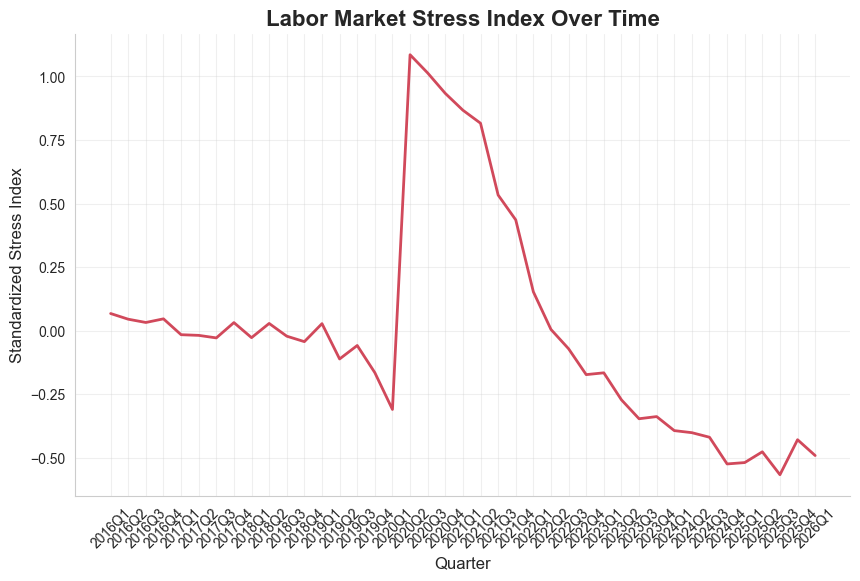

In [23]:
# visualize labor market stress index
import matplotlib.pyplot as plt
import seaborn as sns

# style settings
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10,6),
                     'axes.titlesize': 16,
                     'axes.labelsize': 12,
                     'axes.titleweight': 'bold',
                     'font.family': 'sans-serif',
                     'grid.alpha': 0.3,
                     'lines.linewidth': 2,})
# custom color palette for plots
palette = {'stress': '#D1495B',
           'burnout': '#00798C',
           'prediction': '#EDA63B',
           'economic': '#30638E'}

plt.figure()
plt.plot(master_df['quarter'],
         master_df['labor_market_stress_index'],
         color = palette["stress"])
plt.title('Labor Market Stress Index Over Time')
plt.xlabel('Quarter')
plt.ylabel('Standardized Stress Index')
plt.xticks(rotation = 45)

sns.despine()
plt.show()

#### Real Wage Growth

In [25]:
# nominal wage growth
master_df['wage_growth'] = master_df['hourly_earnings'].pct_change()
# inflation rate based on cpi growth
master_df['inflation_rate'] = master_df['cpi'].pct_change()
# real wage growth = wage growth minus inflation
master_df['real_wage_growth'] = (master_df['wage_growth'] - master_df['inflation_rate'])
# smooth using 4-quarter rolling mean
master_df['real_wage_growth_rolling'] = (master_df['real_wage_growth']
                                         .rolling(window = 4)
                                         .mean())

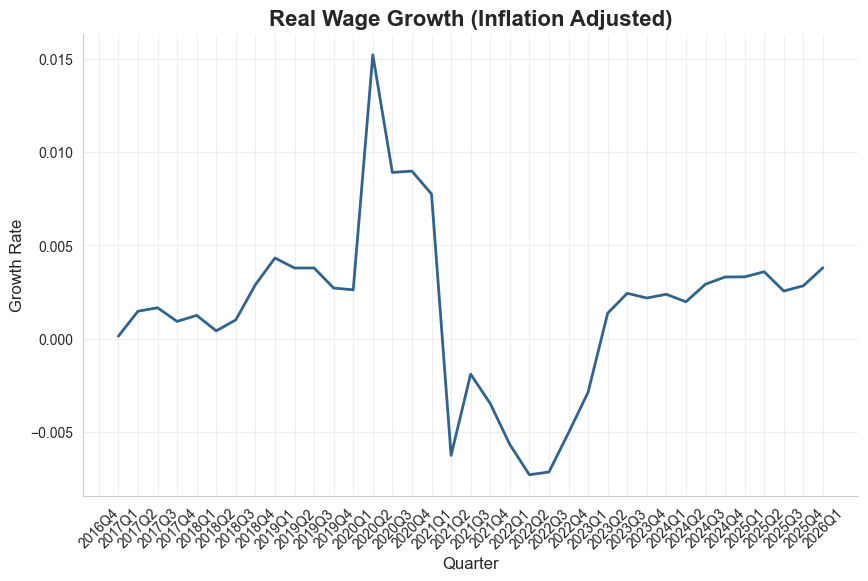

In [26]:
# plot
plt.figure()
plt.plot(master_df['quarter'],
         master_df['real_wage_growth_rolling'],
         color = palette["economic"]
)
plt.title('Real Wage Growth (Inflation Adjusted)')
plt.xlabel('Quarter')
plt.ylabel('Growth Rate')
plt.xticks(rotation = 45)

sns.despine()
plt.show()

#### Labor Demand Ratio

In [28]:
# ratio of job openings to unemployment
master_df['labor_demand_ratio'] = master_df['job_openings_rate'] / master_df['unemployment_rate']
# standardized labor demand ratio
master_df['labor_demand_ratio_z'] = scaler.fit_transform(master_df[['labor_demand_ratio']])
# smoothed labor demand ratio
master_df['labor_demand_ratio_roll'] = master_df['labor_demand_ratio'].rolling(window = 4).mean()

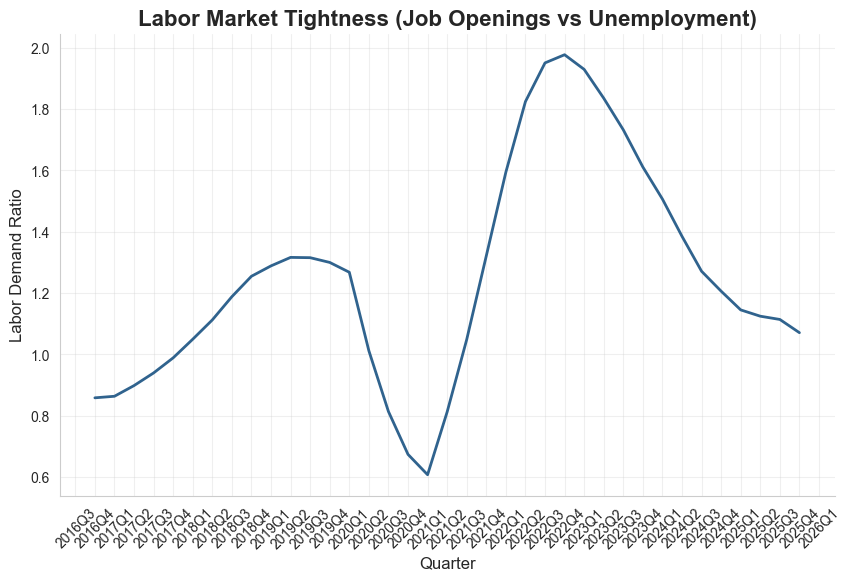

In [29]:
plt.figure()
plt.plot(master_df['quarter'],
         master_df['labor_demand_ratio_roll'],
         color = palette["economic"])
plt.title('Labor Market Tightness (Job Openings vs Unemployment)')
plt.xlabel('Quarter')
plt.ylabel('Labor Demand Ratio')
plt.xticks(rotation = 45)

sns.despine()
plt.show()

#### Lagged Engineered Variables

In [31]:
lag_vars = ['labor_market_stress_index', 'labor_demand_ratio_roll', 'real_wage_growth_rolling',
            'weekly_hours', 'bea_personal_income', 'hps_anxiety_pct', 'hps_depression_pct']
# create 1-quarter lagged versions
for col in lag_vars:
    master_df[col + '_lag1'] = master_df[col].shift(1)
# drop rows with missing lagged data
master_df = master_df.dropna().reset_index(drop = True)

#### Build Model Dataset

In [33]:
target = 'gt_distress_index'
features = ['labor_market_stress_index_lag1', 'labor_demand_ratio_roll_lag1', 'real_wage_growth_rolling_lag1',
            'weekly_hours_lag1', 'bea_personal_income_lag1']
model_df = master_df[features + [target]].dropna().copy()

# split into predictors and target
X = model_df[features]
y = model_df[target]

# train/test split
split_index = int(len(model_df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

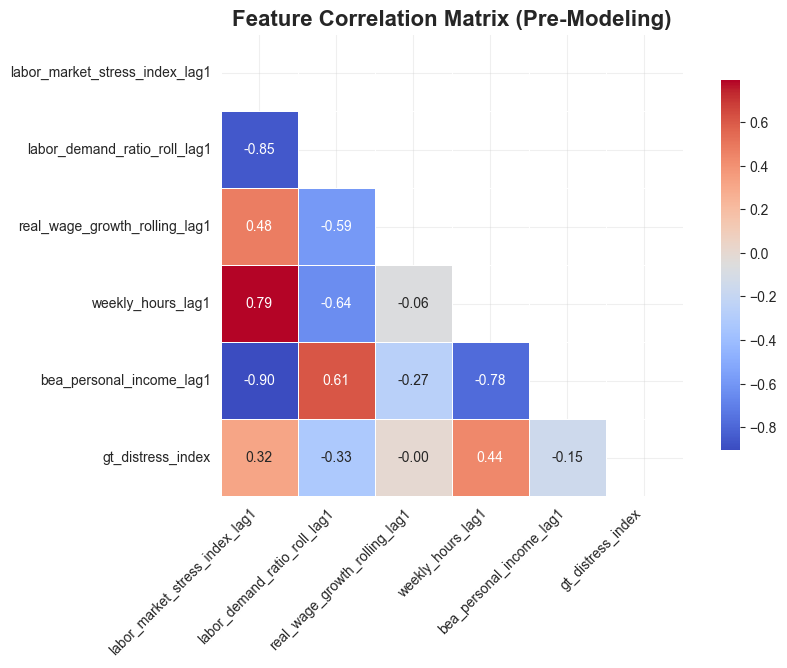

In [34]:
# correlation matrix
corr = model_df.corr(numeric_only = True)

# mask upper triangle for cleaner visualization
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure()

sns.heatmap(corr,
            mask = mask,
            cmap = 'coolwarm',
            annot = True,
            fmt = '.2f',
            linewidths = 0.5,
            square = True,
            cbar_kws = {'shrink': 0.8})

plt.title('Feature Correlation Matrix (Pre-Modeling)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
sns.despine(left = True, bottom = True)

plt.show()

#### Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

# standardize features for linear regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Linear Regression Performance')
print('RMSE:', mean_squared_error(y_test, y_pred_lr, squared=False))
print('R2:', r2_score(y_test, y_pred_lr))

Linear Regression Performance
RMSE: 2.443912644931505
R2: -5.282979614292793


#### Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 500, random_state = 42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Performance')
print('RMSE:', mean_squared_error(y_test, y_pred_rf, squared=False))
print('R2:', r2_score(y_test, y_pred_rf))

Random Forest Performance
RMSE: 1.0074930995688598
R2: -0.06777181818166778


#### XGBoost

In [40]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators = 500,
                   learning_rate = 0.05,
                   max_depth = 4,
                   random_state = 42)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost Performance')
print('RMSE:', mean_squared_error(y_test, y_pred_xgb, squared=False))
print('R2:', r2_score(y_test, y_pred_xgb))

XGBoost Performance
RMSE: 1.0302985081239697
R2: -0.11665865302910072


#### Initial Models Comparison

In [42]:
model_results = {'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
                 'RMSE': [mean_squared_error(y_test, y_pred_lr, squared = False),
                          mean_squared_error(y_test, y_pred_rf, squared = False),
                          mean_squared_error(y_test, y_pred_xgb, squared = False)],
                 'R2': [r2_score(y_test, y_pred_lr),
                        r2_score(y_test, y_pred_rf),
                        r2_score(y_test, y_pred_xgb)]}

results_df = pd.DataFrame(model_results)
print(results_df)

               Model      RMSE        R2
0  Linear Regression  2.443913 -5.282980
1      Random Forest  1.007493 -0.067772
2            XGBoost  1.030299 -0.116659


#### Feature Importance & Plot

In [44]:
rf_importance = pd.DataFrame({'feature': features,
                              'importance': rf.feature_importances_
                             }).sort_values('importance', ascending = False)

print(rf_importance)

                          feature  importance
1    labor_demand_ratio_roll_lag1    0.307981
0  labor_market_stress_index_lag1    0.185076
2   real_wage_growth_rolling_lag1    0.176233
3               weekly_hours_lag1    0.168097
4        bea_personal_income_lag1    0.162614


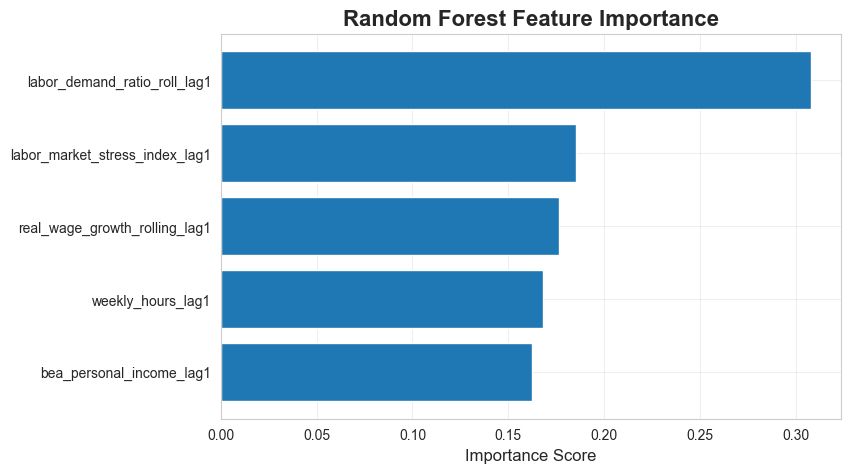

In [45]:
plt.figure(figsize = (8,5))
plt.barh(rf_importance['feature'], rf_importance['importance'])
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')

plt.show()

In [46]:
xgb_importance = pd.DataFrame({'feature': features, 'importance': xgb.feature_importances_
                              }).sort_values('importance', ascending = False)

print(xgb_importance)

                          feature  importance
1    labor_demand_ratio_roll_lag1    0.563286
3               weekly_hours_lag1    0.190154
2   real_wage_growth_rolling_lag1    0.139869
0  labor_market_stress_index_lag1    0.058012
4        bea_personal_income_lag1    0.048678


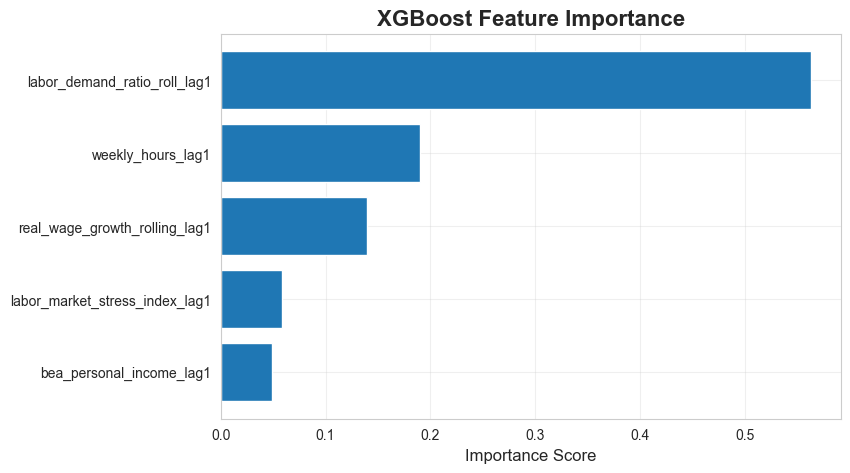

In [47]:
plt.figure(figsize = (8,5))
plt.barh(xgb_importance['feature'], xgb_importance['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

#### Random Forest Predicted vs Actual Plot

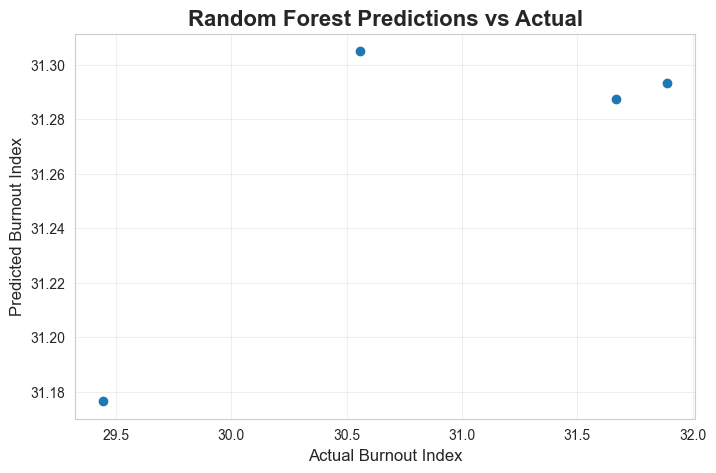

In [49]:
plt.figure(figsize = (8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Burnout Index')
plt.ylabel('Predicted Burnout Index')
plt.title('Random Forest Predictions vs Actual')
plt.show()

#### Changed-Based Features

In [51]:
# quarter-to-quarter changes in key predictors
master_df['stress_change'] = master_df['labor_market_stress_index'].diff()
master_df['wage_change'] = master_df['real_wage_growth_rolling'].diff()
master_df['demand_change'] = master_df['labor_demand_ratio_roll'].diff()
master_df['hours_change'] = master_df['weekly_hours'].diff()

# lagged changes
master_df['stress_change_lag1'] = master_df['stress_change'].shift(1)
master_df['wage_change_lag1'] = master_df['wage_change'].shift(1)
master_df['demand_change_lag1'] = master_df['demand_change'].shift(1)
master_df['hours_change_lag1'] = master_df['hours_change'].shift(1)

# define burnout change as target
master_df['burnout_change'] = master_df['gt_distress_index'].diff()

target = 'burnout_change'
features = ['stress_change_lag1', 'wage_change_lag1',
            'demand_change_lag1', 'hours_change_lag1']

# random forest configured for change prediction
rf = RandomForestRegressor(n_estimators = 300,
                           max_depth = 3,
                           min_samples_leaf = 2,
                           random_state = 42)

In [52]:
# time-series cross-validation
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    rmse = mean_squared_error(y_test, preds, squared = False)
    scores.append(rmse)

print('Average RMSE:', np.mean(scores))

Average RMSE: 1.3762243016893305


#### Add Time Trend and Seasonality

In [54]:
# re-sort data and create time index
master_df = master_df.sort_values('quarter').reset_index(drop = True)
master_df['time_index'] = range(len(master_df))

# extract quarter number for seasonality
master_df['quarter_num'] = master_df['quarter'].str[-1].astype(int)

features = ['stress_change_lag1', 'wage_change_lag1', 'demand_change_lag1',
            'hours_change_lag1', 'time_index', 'quarter_num']

In [55]:
# rebuild modeling dataset
model_df = master_df[features + [target]].dropna().copy()

X = model_df[features]
y = model_df[target]

rf = RandomForestRegressor(n_estimators = 300,
                           max_depth = 3,
                           min_samples_leaf = 2,
                           random_state = 42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(rmse)

0.5068312269254647


#### Plot Labor Stress vs Burnout Trend

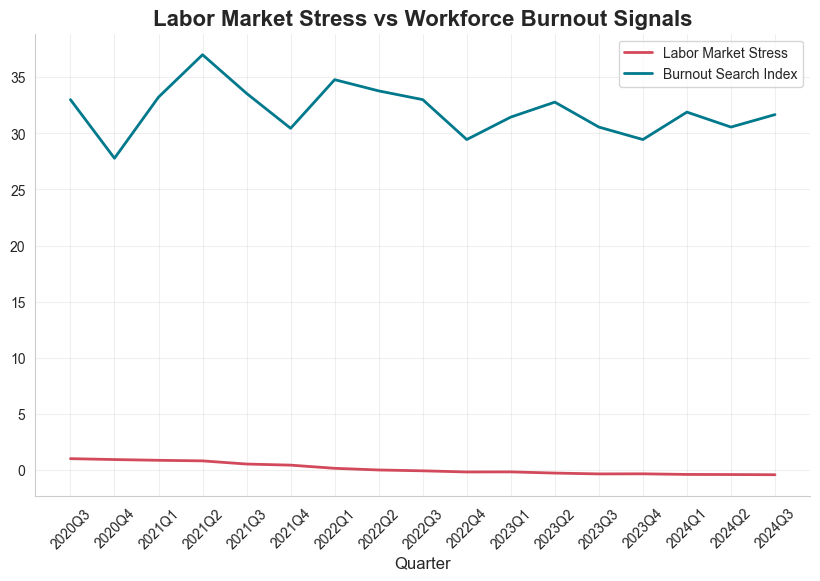

In [57]:
plt.figure()
plt.plot(master_df['quarter'],
         master_df['labor_market_stress_index'],
         label = 'Labor Market Stress',
         color = palette['stress'])
plt.plot(master_df['quarter'],
         master_df['gt_distress_index'],
         label = 'Burnout Search Index',
         color = palette['burnout'])
plt.legend()
plt.title('Labor Market Stress vs Workforce Burnout Signals')
plt.xlabel('Quarter')
plt.xticks(rotation = 45)

sns.despine()
plt.show()

#### Plot Random Forest Feature Importance

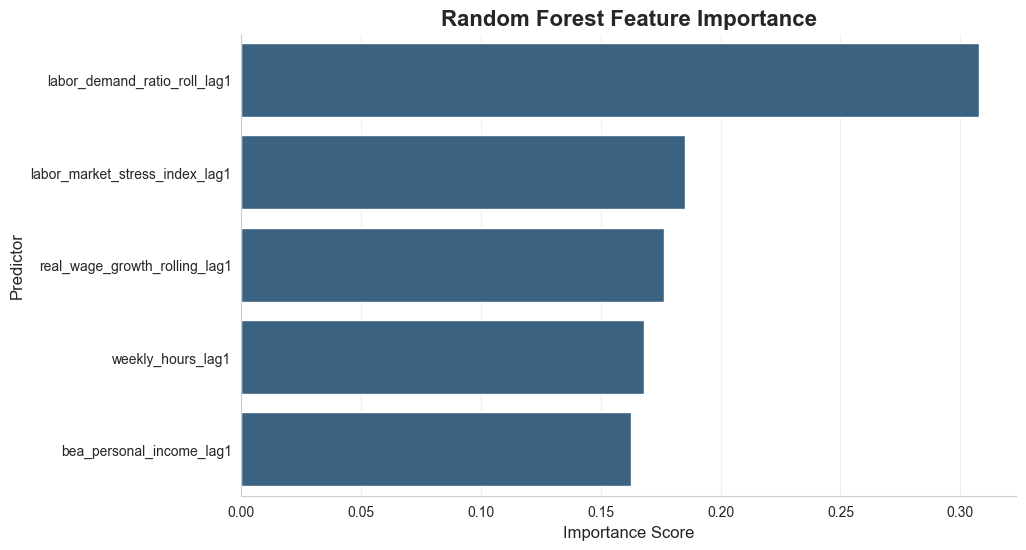

In [59]:
plt.figure()
sns.barplot(x = 'importance',
            y = 'feature',
            data = rf_importance,
            color = palette['economic'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Predictor')

sns.despine()
plt.show()

#### Plot Actual vs Predicted Burnout

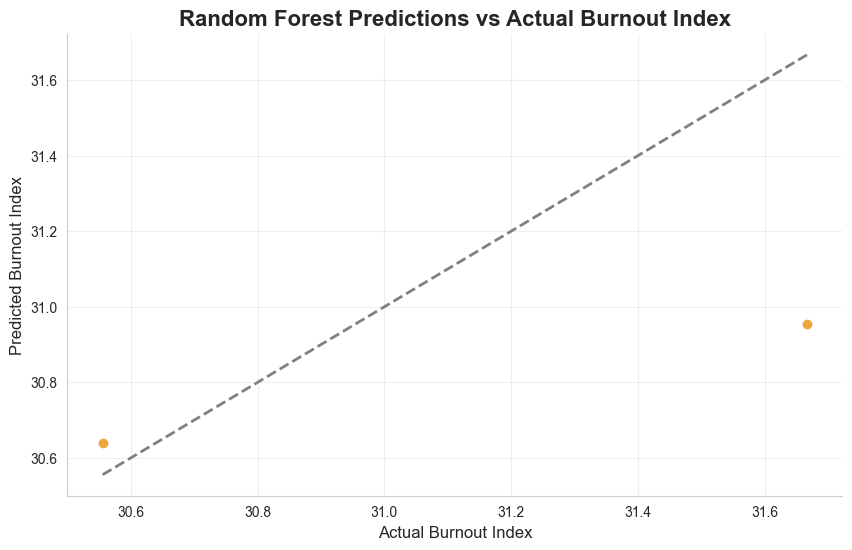

In [62]:
plt.figure()
plt.scatter(y_test,
            y_pred_rf,
            color = palette['prediction'])
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle = '--',
         color = 'gray')
plt.title('Random Forest Predictions vs Actual Burnout Index')
plt.xlabel('Actual Burnout Index')
plt.ylabel('Predicted Burnout Index')

sns.despine()
plt.show()

#### Final Correlation Matrix

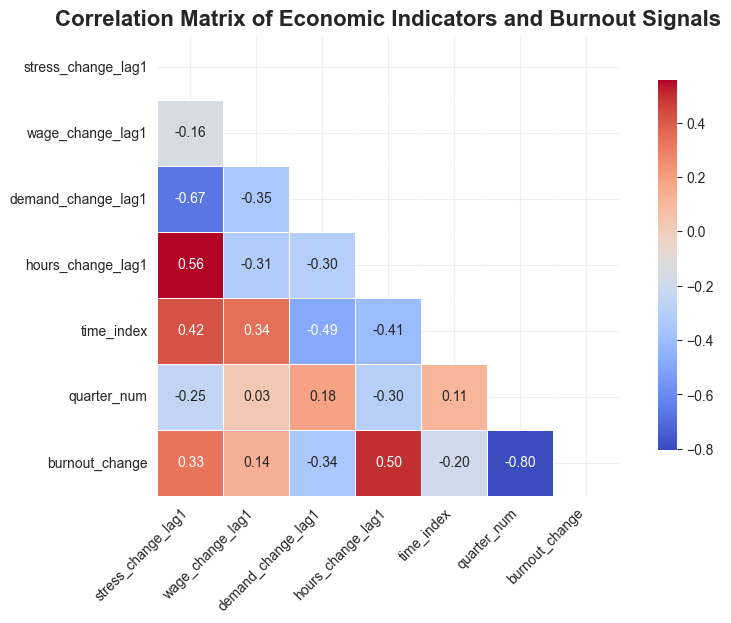

In [64]:
corr = model_df.corr(numeric_only = True)
mask = np.triu(np.ones_like(corr, dtype = bool))

plt.figure()
sns.heatmap(corr,
            mask = mask,
            cmap = 'coolwarm',
            annot = True,
            fmt = '.2f',
            linewidths = 0.5,
            square = True,
            cbar_kws = {'shrink': 0.8})
plt.title('Correlation Matrix of Economic Indicators and Burnout Signals')
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)

sns.despine(left = True, bottom = True)
plt.show()